In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
# Load the dataset
data = pd.read_csv(r"C:\Users\chand\Downloads\healthcare_dataset.csv")

In [18]:
data['Name'] = data['Name'].str.lower().str.title()

In [19]:
# Display the first few rows of the dataset
print(data.head())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby Jackson   30    Male         B-            Cancer        2024-01-31   
1   Leslie Terry   62    Male         A+           Obesity        2019-08-20   
2    Danny Smith   76  Female         A-           Obesity        2022-09-22   
3   Andrew Watts   28  Female         O+          Diabetes        2020-11-18   
4  Adrienne Bell   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

In [20]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [5]:
print(data.describe())

                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [6]:
print(data.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [21]:
print(data.duplicated().sum())

534


In [22]:
duplicates = data[data.duplicated()]
duplicates.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
50023,Samuel Joyce,56,Male,O+,Arthritis,2022-11-03,Krista Hartman,Thomas-Ballard,UnitedHealthcare,15654.830587,157,Urgent,2022-11-22,Aspirin,Inconclusive
50040,Kimberly Vasquez,26,Male,A-,Obesity,2023-10-23,Jennifer Bennett,Cowan Inc,UnitedHealthcare,38142.109678,313,Urgent,2023-11-18,Penicillin,Abnormal
50055,Scott Thornton,55,Female,B-,Obesity,2021-04-08,Joshua Ingram,Keller LLC,Medicare,30894.904511,455,Urgent,2021-04-15,Aspirin,Abnormal
50070,William Lee,27,Female,O+,Arthritis,2020-01-31,Lauren Montgomery,Winters-Simon,Cigna,46229.434901,153,Elective,2020-02-13,Lipitor,Normal
50078,Christopher Norris,38,Male,AB-,Arthritis,2023-01-14,Denise Blair,Inc Morales,Medicare,9072.127142,452,Emergency,2023-02-12,Penicillin,Normal


In [23]:
data = data.drop_duplicates()

In [25]:
print(data.duplicated().sum())

0


In [8]:
print(data.columns)

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')


In [26]:
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

In [27]:
print(data.columns)

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results'],
      dtype='object')


In [28]:
data['date_of_admission'] = pd.to_datetime(data['date_of_admission'])
data['discharge_date'] = pd.to_datetime(data['discharge_date'])

In [29]:
print(data.dtypes)

name                          object
age                            int64
gender                        object
blood_type                    object
medical_condition             object
date_of_admission     datetime64[ns]
doctor                        object
hospital                      object
insurance_provider            object
billing_amount               float64
room_number                    int64
admission_type                object
discharge_date        datetime64[ns]
medication                    object
test_results                  object
dtype: object


In [30]:
data['length_of_stay'] = (data['discharge_date'] -
                          data['date_of_admission']).dt.days

In [31]:
data[['date_of_admission', 'discharge_date', 'length_of_stay']].head()

,date_of_admission,discharge_date,length_of_stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [33]:
data['length_of_stay'].describe()


count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64

# medical conditions

In [ ]:
# most common conditions
data['medical_condition'].value_counts()

medical_condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

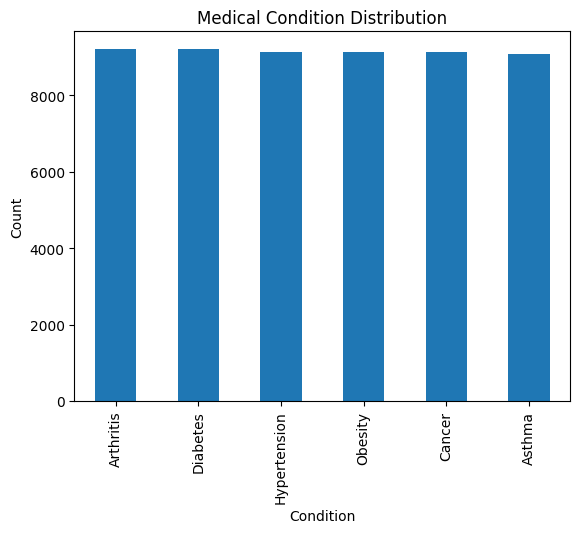

In [38]:
import matplotlib.pyplot as plt

data['medical_condition'].value_counts().plot(kind='bar')
plt.title("Medical Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

# billing vs condition

In [ ]:
# average billing per condition
data.groupby('medical_condition')['billing_amount'].mean()

medical_condition
Arthritis       25511.783246
Asthma          25633.461696
Cancer          25152.322947
Diabetes        25660.478635
Hypertension    25503.058720
Obesity         25804.361902
Name: billing_amount, dtype: float64

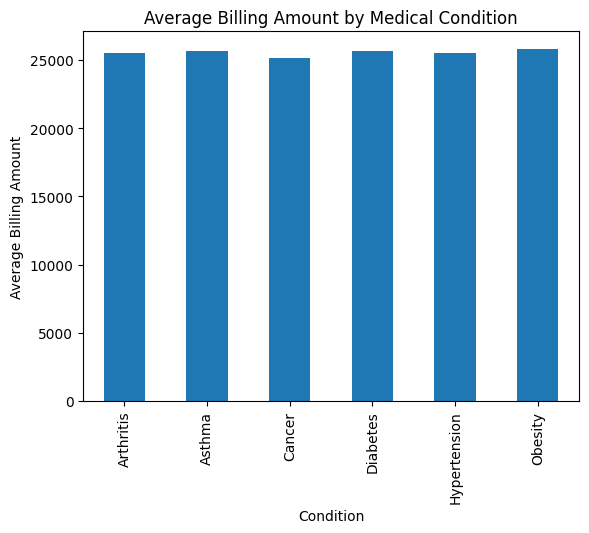

In [40]:
data.groupby('medical_condition')['billing_amount'].mean().plot(kind='bar')

plt.title("Average Billing Amount by Medical Condition")
plt.xlabel("Condition")
plt.ylabel("Average Billing Amount")
plt.show()

# admission_type vs billing_amount

In [ ]:
# Which admission type (Emergency, Elective, Urgent) has the highest average billing amount?
data.groupby('admission_type')['billing_amount'].mean()

admission_type
Elective     25612.139673
Emergency    25505.332240
Urgent       25514.532045
Name: billing_amount, dtype: float64

# hospital vs billing amount?

In [43]:
# Which hospital has the highest total billing amount?
data.groupby('hospital')['billing_amount'].sum().sort_values(ascending=False)

hospital
Johnson PLC                          1.081477e+06
LLC Smith                            1.030190e+06
Smith PLC                            1.029424e+06
Ltd Smith                            1.003366e+06
Smith Ltd                            9.700359e+05
                                         ...     
Clements-Bowman                     -1.277645e+03
Diaz-Bishop                         -1.353705e+03
Fitzpatrick, Nielsen and Mcdonald   -1.774048e+03
Juarez-Clark                        -2.008492e+03
Medina and Elliott Stewart,         -2.633237e+03
Name: billing_amount, Length: 39876, dtype: float64

# medical condition vs length of stay?

In [44]:
# Which medical condition has the highest average length of stay?
data.groupby('medical_condition')['length_of_stay'].mean()

medical_condition
Arthritis       15.504231
Asthma          15.677295
Cancer          15.501204
Diabetes        15.430664
Hypertension    15.436236
Obesity         15.447627
Name: length_of_stay, dtype: float64

# doctor vs condition

In [45]:
# How many cases each doctor handled for each condition
data.groupby(['doctor', 'medical_condition']).size().sort_values(ascending=False)

doctor           medical_condition
John Smith       Arthritis            8
Andrew Williams  Obesity              7
Michael Smith    Hypertension         7
                 Diabetes             6
Michael Johnson  Cancer               6
                                     ..
Aaron Baker      Diabetes             1
Aaron Anderson   Arthritis            1
Zoe Wallace      Diabetes             1
Aaron Baker      Cancer               1
Zachary Ward     Arthritis            1
Length: 47398, dtype: int64

# blood_type vs 'medical_condition'

In [46]:
counts = data.groupby(['blood_type', 'medical_condition']).size()
percentages = counts / counts.groupby(level=0).sum() * 100
percentages = percentages.sort_values(ascending=False)
percentages.head(10)

blood_type  medical_condition
AB+         Hypertension         17.494914
A+          Diabetes             17.415893
O+          Arthritis            17.301240
B+          Arthritis            17.298475
AB-         Cancer               17.253419
B+          Cancer               17.225853
B-          Obesity              17.200233
A-          Hypertension         17.193389
AB-         Arthritis            17.151586
B+          Diabetes             17.138707
dtype: float64

# Length of Stay vs Billing Amount

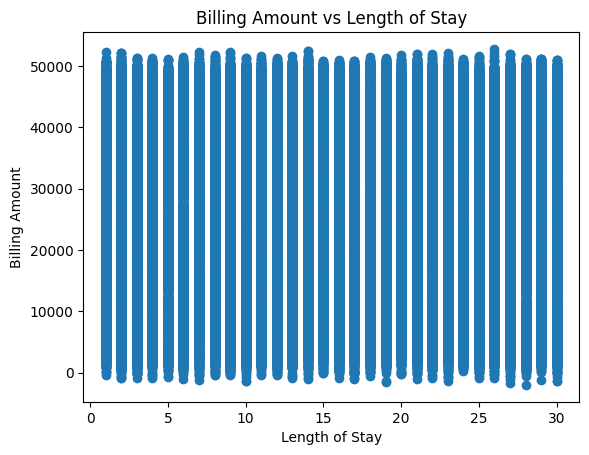

In [47]:
import matplotlib.pyplot as plt

plt.scatter(data['length_of_stay'], data['billing_amount'])
plt.xlabel("Length of Stay")
plt.ylabel("Billing Amount")
plt.title("Billing Amount vs Length of Stay")
plt.show()

# billing vs los

<Axes: xlabel='length_of_stay'>

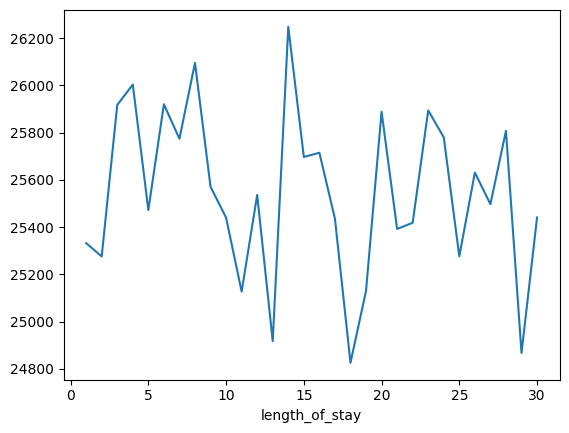

In [48]:
data.groupby('length_of_stay')['billing_amount'].mean().plot()

# Hardcoded Logic (First Version)

In [49]:
def simple_query_system(query):

    if "average billing" in query:
        return data['billing_amount'].mean()

    elif "total billing" in query:
        return data['billing_amount'].sum()

    elif "average stay" in query:
        return data['length_of_stay'].mean()

    else:
        return "Query not understood"

In [50]:
print(simple_query_system("average billing"))
print(simple_query_system("total billing"))
print(simple_query_system("average stay"))

25544.306284383965
1404068339.227449
15.499290470472657


In [51]:
def smarter_query_system(query):

    query = query.lower()

    # detect operation
    if "average" in query:
        operation = "mean"
    elif "total" in query:
        operation = "sum"
    elif "max" in query:
        operation = "max"
    elif "min" in query:
        operation = "min"
    else:
        return "Operation not understood"

    # detect column
    if "billing" in query:
        column = "billing_amount"
    elif "stay" in query:
        column = "length_of_stay"
    else:
        return "Column not understood"

    # execute operation
    if operation == "mean":
        return data[column].mean()
    elif operation == "sum":
        return data[column].sum()
    elif operation == "max":
        return data[column].max()
    elif operation == "min":
        return data[column].min()

In [52]:
print(smarter_query_system("what is average billing amount?"))
print(smarter_query_system("total billing"))
print(smarter_query_system("max stay"))

25544.306284383965
1404068339.227449
30


In [53]:
operation_map = {
    "average": "mean",
    "mean": "mean",
    "total": "sum",
    "sum": "sum",
    "maximum": "max",
    "max": "max",
    "minimum": "min",
    "min": "min",
    "count": "count"
}

column_map = {
    "billing": "billing_amount",
    "cost": "billing_amount",
    "charge": "billing_amount",
    "stay": "length_of_stay",
    "length of stay": "length_of_stay",
    "age": "age"
}

In [56]:
import matplotlib.pyplot as plt


def final_query_system(query):
    query = query.lower()

    # detect operation
    operation = None
    for key in operation_map:
        if key in query:
            operation = operation_map[key]
            break

    # detect column
    column = None
    for key in column_map:
        if key in query:
            column = column_map[key]
            break

    # detect group by
    group_by = None
    if "medical condition" in query:
        group_by = "medical_condition"
    elif "hospital" in query:
        group_by = "hospital"
    elif "admission type" in query:
        group_by = "admission_type"

    # validation
    if operation is None:
        return "Operation not understood"

    if column is None:
        return "Column not understood"

    # execute
    if group_by:
        result = getattr(data.groupby(group_by)[column], operation)()
        result.plot(kind='bar')
        plt.title(f"{operation} of {column} by {group_by}")
        plt.xlabel(group_by)
        plt.ylabel(operation)
        plt.show()
        return result
    else:
        result = getattr(data[column], operation)()
        return result

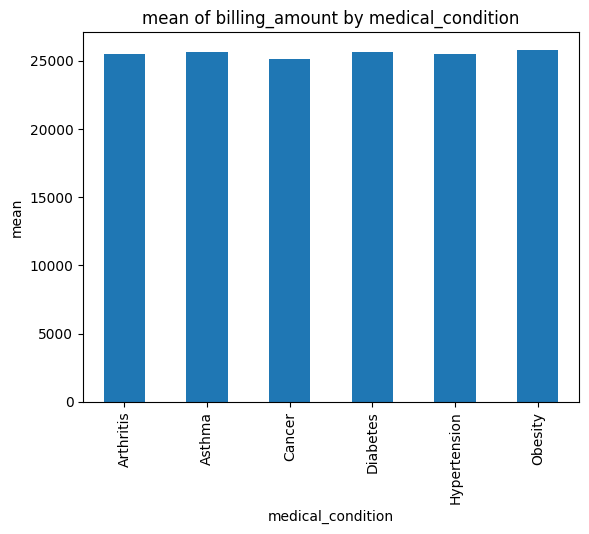

medical_condition
Arthritis       25511.783246
Asthma          25633.461696
Cancer          25152.322947
Diabetes        25660.478635
Hypertension    25503.058720
Obesity         25804.361902
Name: billing_amount, dtype: float64

In [57]:
final_query_system("average billing by medical condition")